### Libraries

In [1]:
import json
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt

import sys
import os
sys.path.append(os.path.abspath(".."))
from Python_Scripts.Inference_Funcs_FMG import (
    load_data,
    plot_diagnostic,
    plot_posterior_distributions,
    plot_posterior_predictive,
    plot_posterior_predictive_checks,
    plot_pairplot
)

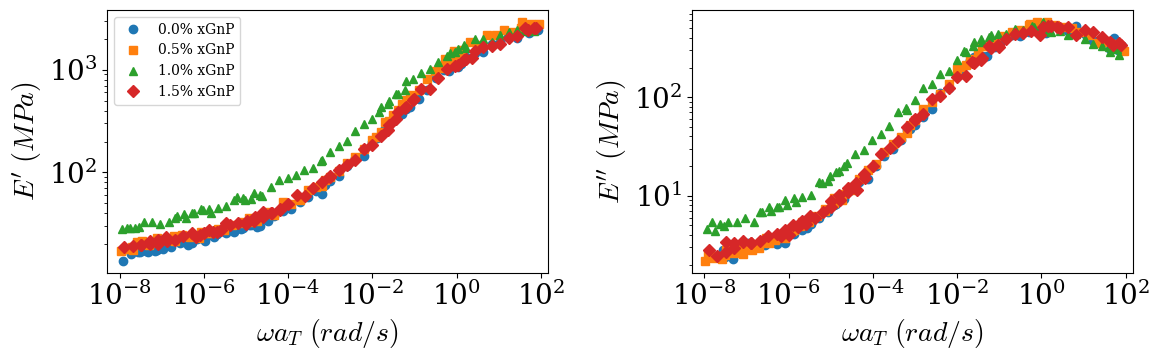

In [ ]:
# ------------------------------------------------------------
# Set up argument parsing and load configuration and data
# ------------------------------------------------------------
# Load configuration and data
HS = 20
with open(f'../configs/{HS}HSWF_FMG_Config.json', 'r') as config_file:
    config = json.load(config_file)

file_path = config['file_path']
sheet_name = config['sheet_name']
rows = config['rows']
cols_opt = config['cols_opt']
cols_GnP = config['cols_GnP']
GnPs = config['GnPs']
omega_limits = config['omega_limits']

rcParams_plot = config['rcParams_plot']

v_obs_Ep, v_obs_Epp, x_data, optimized_params_df = load_data(file_path, sheet_name, rows, cols_opt, cols_GnP, omega_limits, rcParams_plot)

param_list = ['E_c1', 'alpha_1', 'E_c2', 'alpha_2', 'sigma_Ep', 'sigma_Epp']
actual_param_name = [r'$E_{c_1}$', r'$\alpha_1$', r'$E_{c_2}$', r'$\alpha_2$',
                    r'$\sigma_{E^{\prime}}$', r'$\sigma_{E^{\prime\prime}}$']

# Load the inference data
idata_dict = {}
for GnP in GnPs:
    idata_dict[GnP] = az.from_netcdf(f"../Results/MCMC_FMG_{HS}HSWF/EpEpp_FMG_{HS}HS_{GnP}.nc")
df_mean_inference = pd.read_csv(f"../Results/MCMC_FMG_{HS}HSWF/Mean_Inference_{HS}HS_FMG.csv")
idata_mean_dict = df_mean_inference.set_index('GnP').to_dict(orient='index')

df_std_inference = pd.read_csv(f"../Results/MCMC_FMG_{HS}HSWF/std_Inference_{HS}HS_FMG.csv")
idata_std_dict = df_std_inference.set_index('GnP').to_dict(orient='index')

df_map_estimate = pd.read_csv(f"../Results/MCMC_FMG_{HS}HSWF/Map_Estimate_{HS}HS_FMG.csv")
map_estimate_dict = df_map_estimate.set_index('GnP').to_dict(orient='index')

df_error_measures = pd.read_csv(f"../Results/MCMC_FMG_{HS}HSWF/Error_Measures_{HS}HS_FMG.csv")
error_measures_dict = df_error_measures.set_index('GnP').to_dict(orient='index')

optimized_params_df['GnP'] = ['0.0GnP', '0.5GnP', '1.0GnP', '1.5GnP']
optimized_params_dict = optimized_params_df.set_index('GnP').to_dict(orient='index')

# Plot settings
plt.rcParams.update({
    'font.size': rcParams_plot['font.size'],
    'axes.labelsize': rcParams_plot['axes.labelsize'],
    'xtick.labelsize': rcParams_plot['xtick.labelsize'],
    'ytick.labelsize': rcParams_plot['ytick.labelsize'],
    'legend.fontsize': rcParams_plot['legend.fontsize'],
    'axes.titlesize': rcParams_plot['axes.titlesize'],
    'font.family': rcParams_plot['font.family'],
    'mathtext.fontset': rcParams_plot['mathtext.fontset'],
    'mathtext.rm': rcParams_plot['mathtext.rm'],
    'mathtext.it': rcParams_plot['mathtext.it'],
    'mathtext.bf': rcParams_plot['mathtext.bf']
})

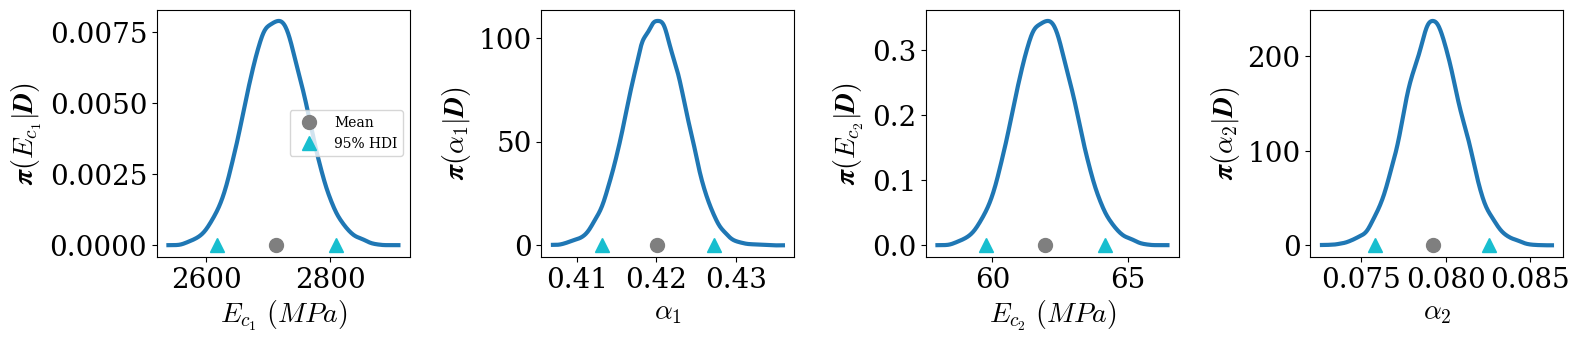

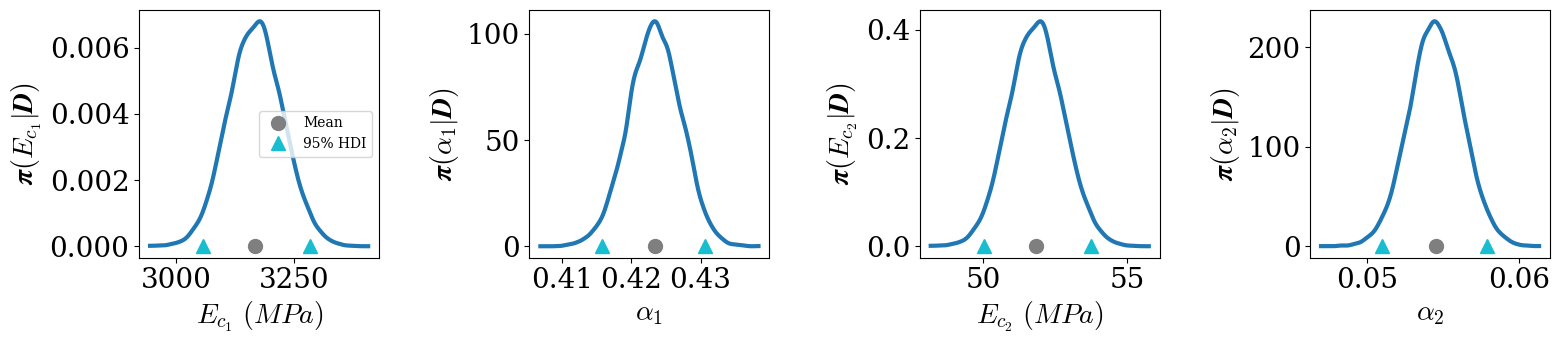

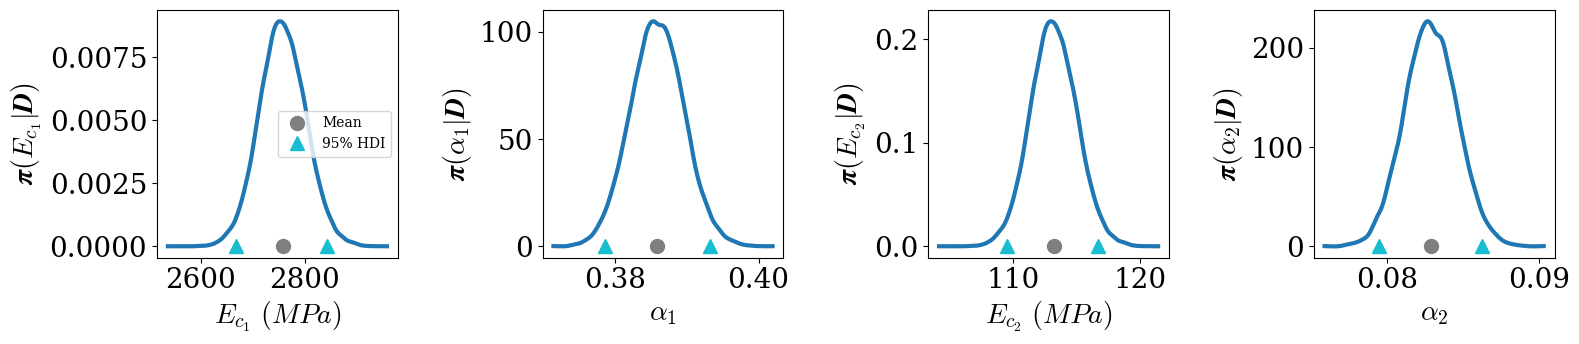

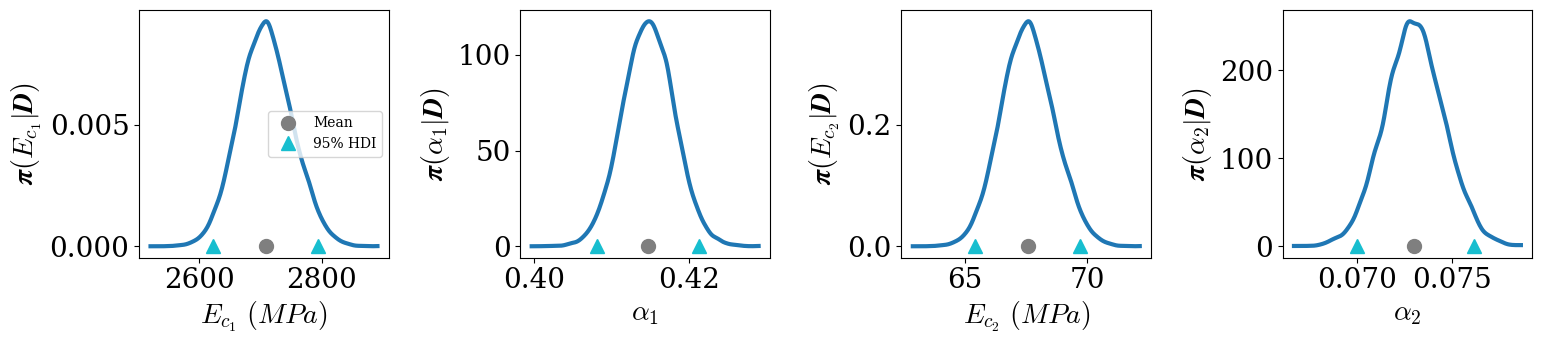

In [ ]:
# --------------------------------------------------
# Posterior distribution plots
# --------------------------------------------------
for GnP_idx in range(len(GnPs)):
    plt_set = {
        "savefig_path": f"{file_path['file_path_save']}/Posterior_FMG_{HS}HS_{GnPs[GnP_idx]}.png"
    }
    os.makedirs(os.path.dirname(file_path['file_path_save']), exist_ok=True)
    plot_posterior_distributions(
        idata_dict[GnPs[GnP_idx]], idata_mean_dict[GnPs[GnP_idx]],
        param_list, actual_param_name, plt_set, rcParams_plot
    )

hdi_prob = 0.95
model_param_hdi_dict = {}
for GnP in GnPs:
    idata = idata_dict[GnP]
    model_param_hdi_dict[GnP] = {
        'E_c1': az.hdi(idata.posterior['E_c1'].values.flatten(), hdi_prob=hdi_prob),
        'E_c2': az.hdi(idata.posterior['E_c2'].values.flatten(), hdi_prob=hdi_prob),
        'alpha_1': az.hdi(idata.posterior['alpha_1'].values.flatten(), hdi_prob=hdi_prob),
        'alpha_2': az.hdi(idata.posterior['alpha_2'].values.flatten(), hdi_prob=hdi_prob)
    }

wide_rows = []

for GnP, params in model_param_hdi_dict.items():
    row = {'GnP': GnP}
    for param_name, hdi_vals in params.items():
        row[f"{param_name}_lower"] = hdi_vals[0]
        row[f"{param_name}_upper"] = hdi_vals[1]
    wide_rows.append(row)

df_hdi_wide = pd.DataFrame(wide_rows)
df_hdi_wide.to_csv(f"{file_path['file_path_save']}/Model_Param_HDI_FMG_{HS}HS.csv", index=False)

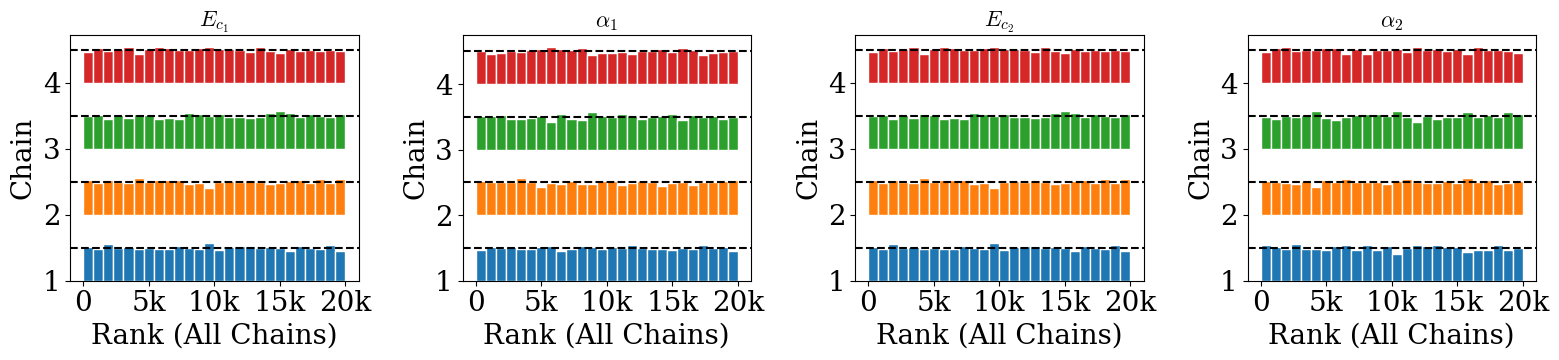

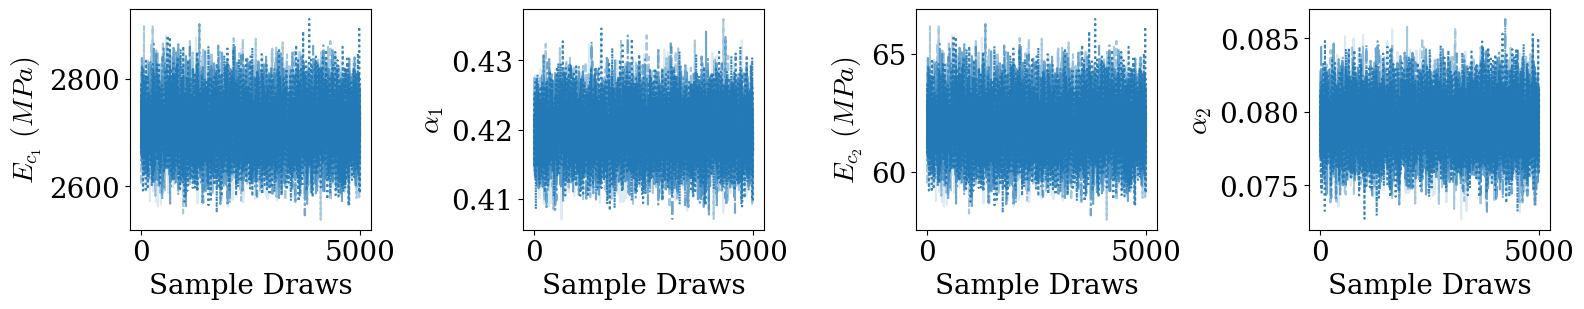

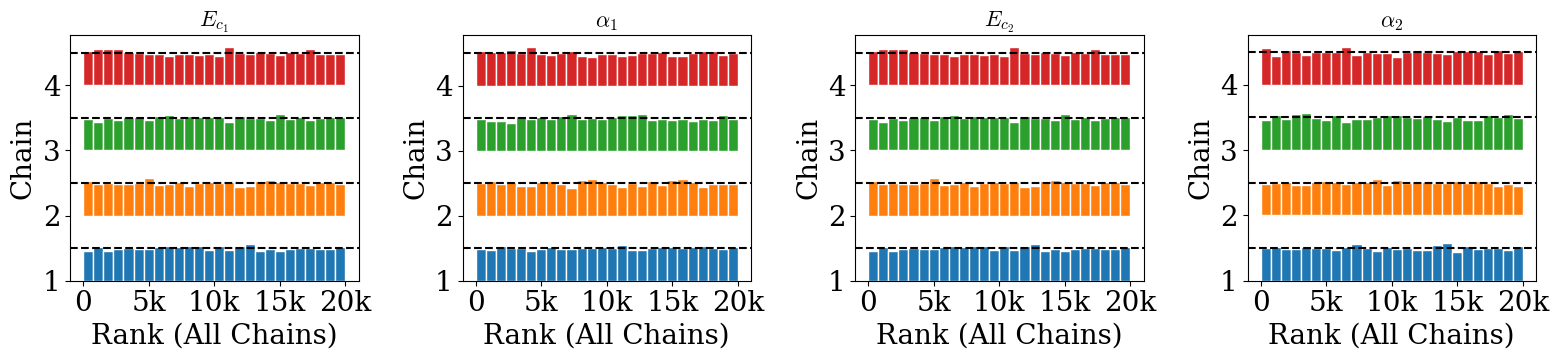

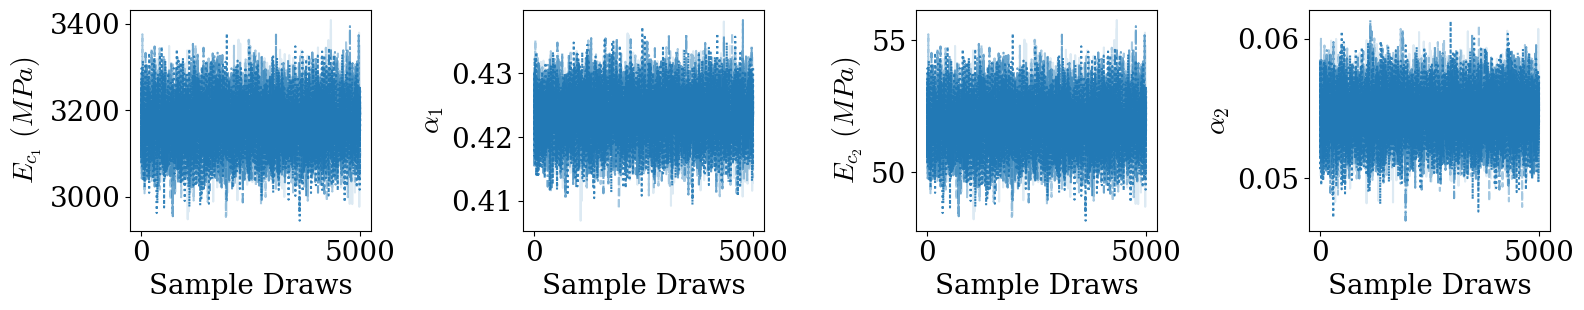

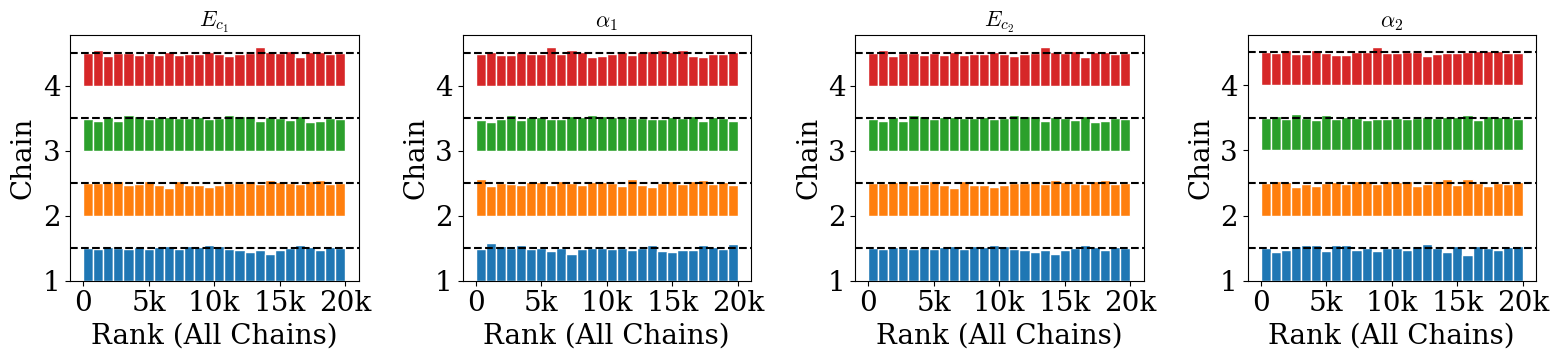

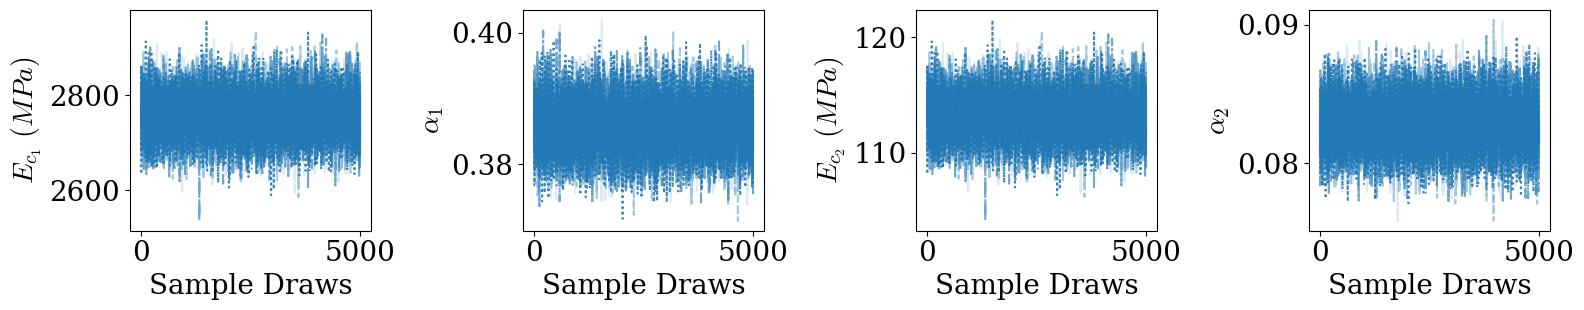

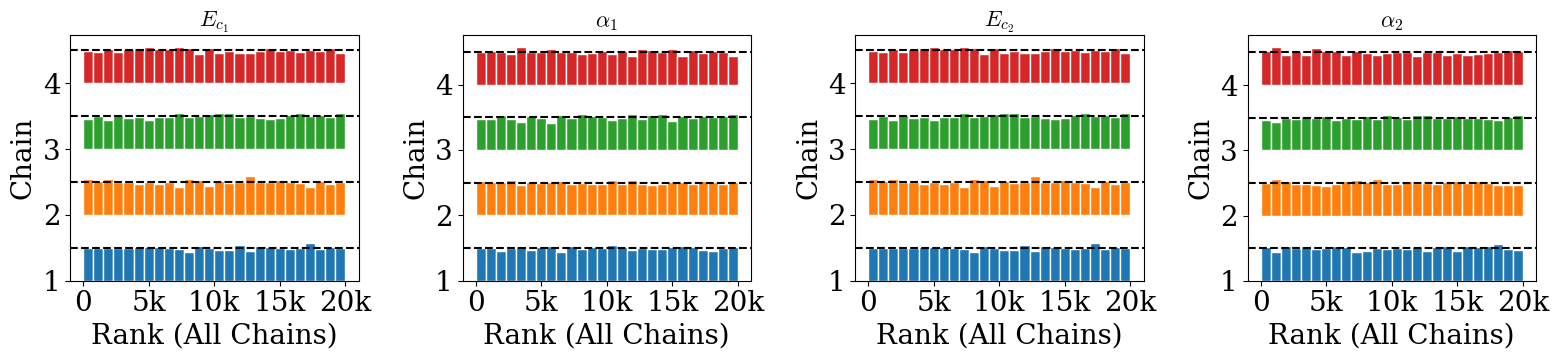

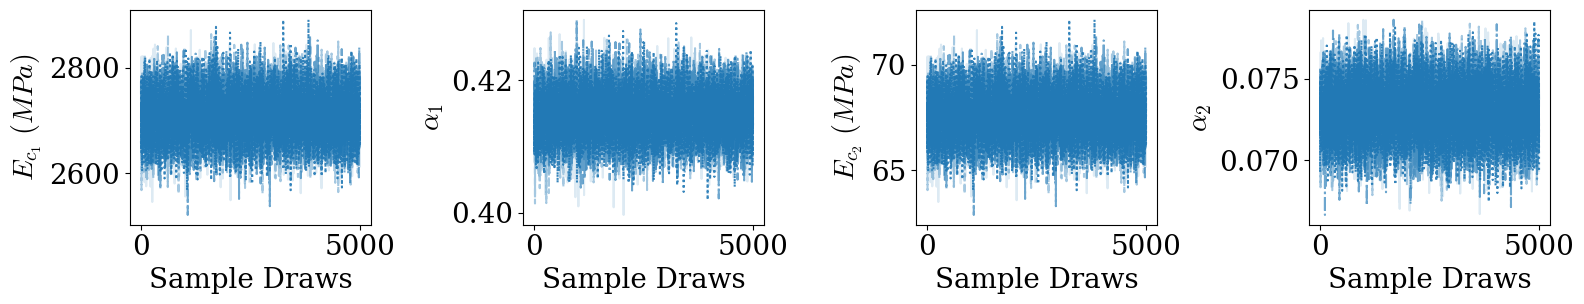

In [ ]:
# --------------------------------------------------
# Rank plots and trace plots
# --------------------------------------------------
var_names = param_list[:4]
xticks = np.linspace(0, config['hyperparams']['draws'] * config['hyperparams']['chains'], 5).tolist()
xtickslabels = ['0', '5k', '10k', '15k', '20k']
for GnP in idata_dict.keys():
    idata = idata_dict[GnP]
    plt_set = {
        "savefig_path_rank": f"{file_path['file_path_save']}/Rank_Plots_FMG_{HS}HS_{GnP}.png",
        "savefig_path_trace": f"{file_path['file_path_save']}/Trace_Plots_FMG_{HS}HS_{GnP}.png"
    }
    plot_diagnostic(idata, var_names, xticks, xtickslabels, plt_set, rcParams_plot)

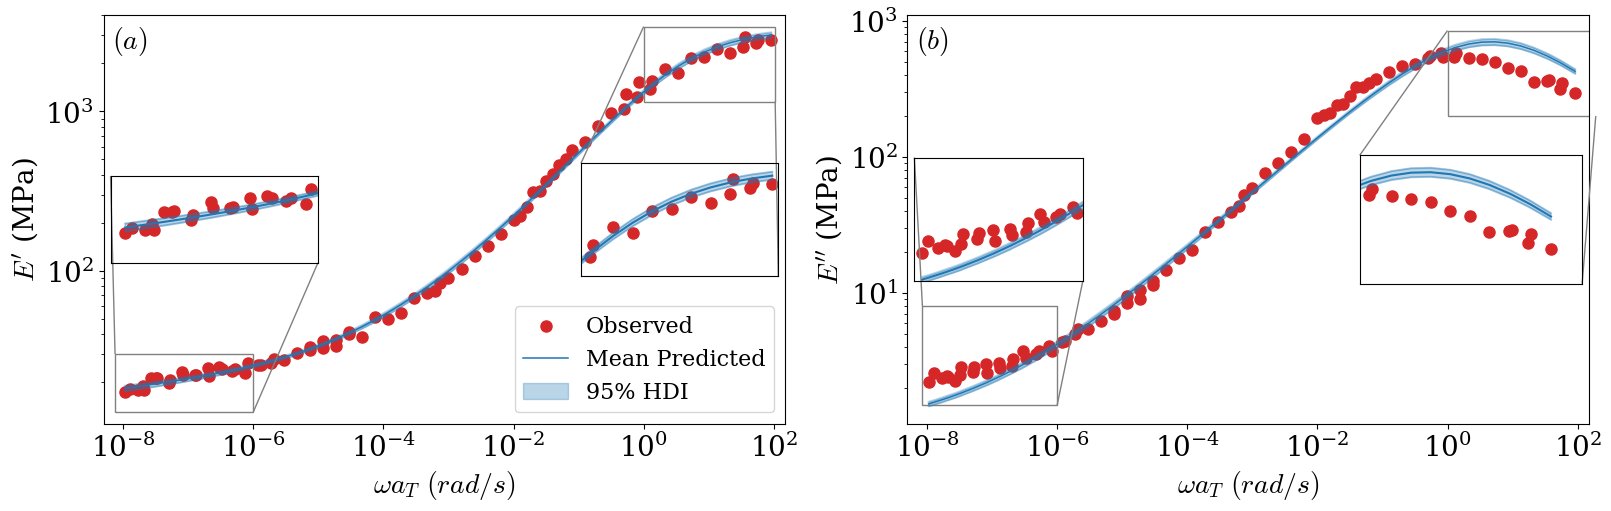

In [10]:
# --------------------------------------------------
# Plot posterior predictive with HDI
# --------------------------------------------------
GnP_idx = 1
xylims = {
    'Ep_inset1': {
        'xlim': [0.75e-8, 1e-6], # HS=20: [0.75e-8, 1e-6], HS=30: [1e-8, 1e-6], HS=40: [1e-8, 1e-6]
        'ylim': [13, 30], # HS=20: [13, 30], HS=30: [70, 170], HS=40: [200, 500]
        'loc': 'center left' # HS=20: center left, HS=30: lower left, HS=40: lower left
    },
    'Ep_inset2': {
        'xlim': [1, 105], # HS=20: [1, 105], HS=30: [1, 100], HS=40: [0.75, 120]
        'ylim': [1150, 3400], # HS=20: [1150, 3400], HS=30: [1250, 3400], HS=40: [1500, 3500]
        'loc': 'center right' # HS=20: center right, HS=30: center right, HS=40: center right
    },
    'Epp_inset3': {
        'xlim': [1, 190], # HS=20: [1, 190], HS=30: [0.2, 25], HS=40: [0.75, 115]
        'ylim': [200, 850], # HS=20: [200, 850], HS=30: [180, 850], HS=40: [200, 650]
        'loc': 'center right' # HS=20: center right, HS=30: center right, HS=40: center right
    },
    'Epp_inset4': {
        'xlim': [0.85e-8, 1e-6], # HS=20: [0.85e-8, 1e-6], HS=30: [0.85e-8, 1e-6], HS=40: [0.75e-8, 1e-6]
        'ylim': [1.5, 8], # HS=20: [1.5, 8], HS=30: [8, 30], HS=40: [15, 50]
        'loc': 'center left' # HS=20: center left, HS=30: lower left, HS=40: lower left
    },
}
plt_set = {
    "savefig_path": f"{file_path['file_path_save']}/Posterior_Predictive_FMG_{HS}HS_{GnPs[GnP_idx]}.png"
}
plot_posterior_predictive(idata_dict, v_obs_Ep, v_obs_Epp, x_data, GnPs, GnP_idx, xylims, plt_set, rcParams_plot)

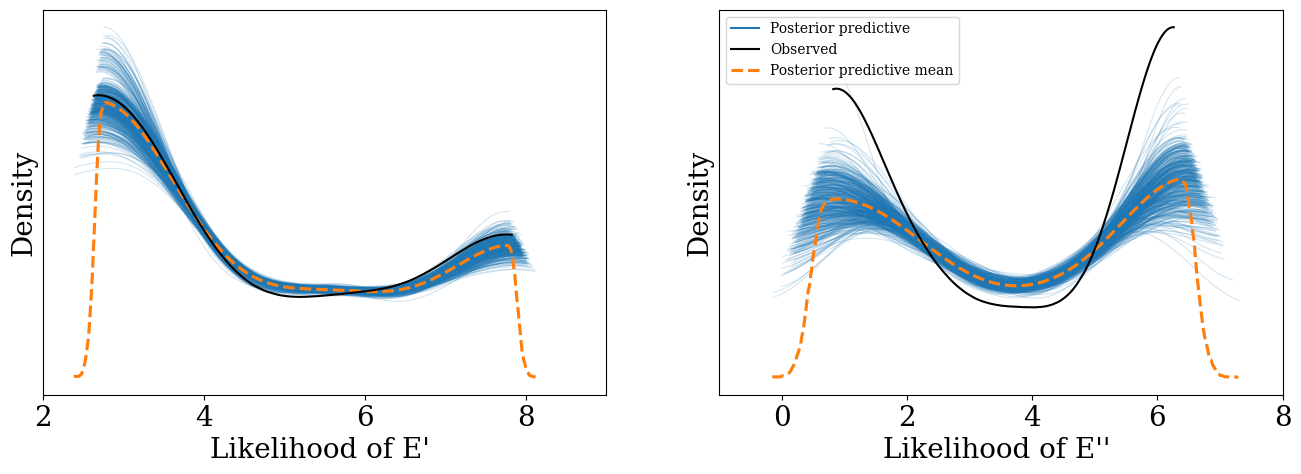

In [ ]:
# --------------------------------------------------
# Plot posterior predictive checks
# --------------------------------------------------
GnP_idx = 0

if HS == 20: 
    range1 = [2, 9]
    range2 = [-1, 8]
elif HS == 30:
    range1 = [4.5, 8.5]
    range2 = [2, 6.5]
else:
    range1 = [5, 8.5]
    range2 = [2.5, 6.5]
plt_set = {
    "savefig_path": f"{file_path['file_path_save']}/Posterior_Predictive_Checks_FMG_{HS}HS_{GnPs[GnP_idx]}.png"
}
plot_posterior_predictive_checks(idata_dict[GnPs[GnP_idx]], range1, range2, plt_set, rcParams_plot)

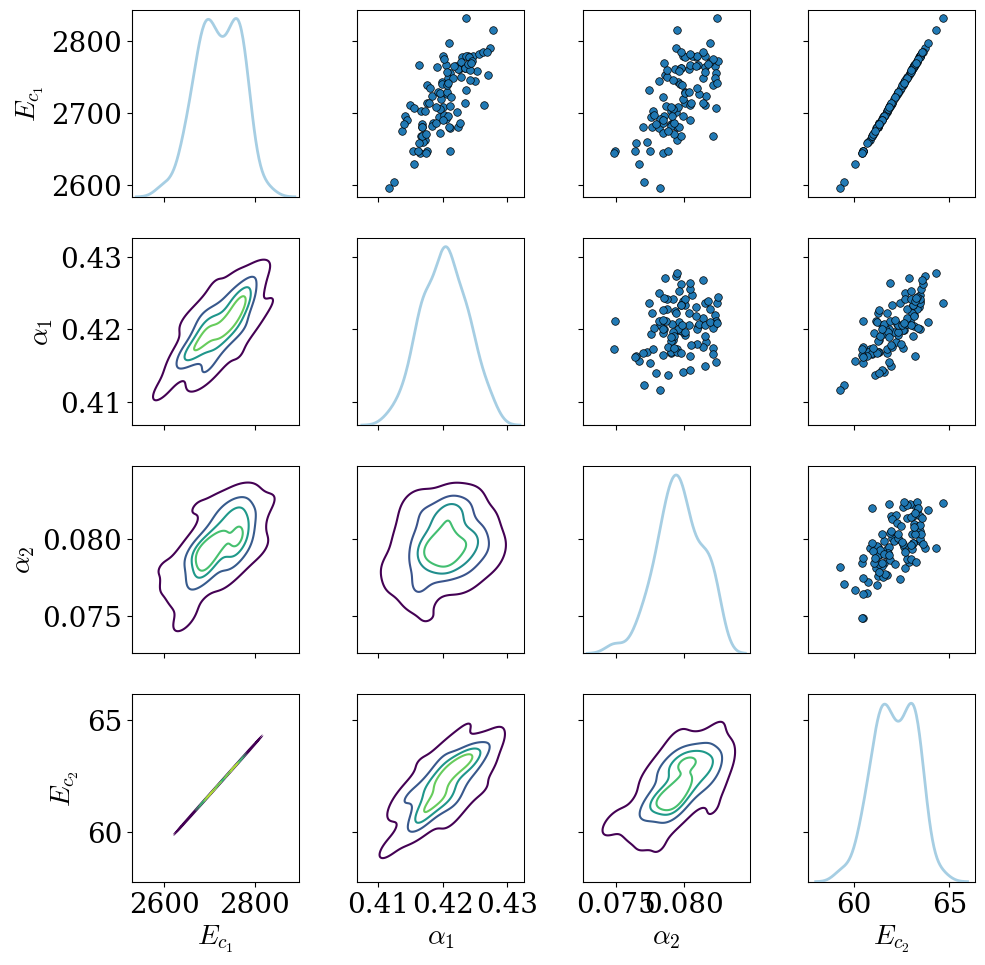

In [ ]:
# --------------------------------------------------
# Pairplots
# --------------------------------------------------
plt_set = {
    "savefig_path": f"{file_path['file_path_save']}/Pairplot_FMG_{HS}HS_{GnPs[0]}.png"
}
plot_pairplot(idata_dict[GnPs[0]], ['E_c1', 'alpha_1', 'alpha_2', 'E_c2'], 100, plt_set, rcParams_plot)